In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df1 = pd.read_csv("/content/merged_players.csv")
df2 = pd.read_csv("/content/Players_round_by_round_stat_cleaned.csv")


In [36]:
df1.shape

(25072, 69)

In [37]:
df2.shape

(274079, 35)

In [38]:
df1.columns.to_list()

['player_id',
 'player_name',
 'player_full_name',
 'first_name',
 'last_name',
 'born_date',
 'debut_date',
 'debut_age',
 'last_date',
 'last_age',
 'height',
 'weight',
 'profile_pic',
 'player_link',
 'player_common_names',
 'player_teams',
 'year',
 'team',
 'is_finals',
 'games_played',
 'kicks',
 'marks',
 'handballs',
 'disposals',
 'goals',
 'behinds',
 'hit_outs',
 'tackles',
 'rebound_50s',
 'inside_50s',
 'clearances',
 'clangers',
 'free_kicks_for',
 'free_kicks_against',
 'brownlow_votes',
 'contested_possessions',
 'uncontested_possessions',
 'contested_marks',
 'marks_inside_50',
 'one_percenters',
 'bounces',
 'goal_assists',
 'total_score',
 'total_fantasy_points',
 'total_percentage_played',
 'avg_kicks',
 'avg_marks',
 'avg_handballs',
 'avg_disposals',
 'avg_goals',
 'avg_behinds',
 'avg_hit_outs',
 'avg_tackles',
 'avg_rebound_50s',
 'avg_inside_50s',
 'avg_clearances',
 'avg_clangers',
 'avg_free_kicks_for',
 'avg_free_kicks_against',
 'avg_contested_possessions'

In [39]:
df2.columns.to_list()

['id',
 'team',
 'year',
 'career_game_count',
 'opponent',
 'round',
 'result',
 'jersey_num',
 'kicks',
 'marks',
 'handballs',
 'disposals',
 'goals',
 'behinds',
 'hit_outs',
 'tackles',
 'rebound_50s',
 'inside_50s',
 'clearances',
 'clangers',
 'free_kicks_for',
 'free_kicks_against',
 'brownlow_votes',
 'contested_possessions',
 'uncontested_possessions',
 'contested_marks',
 'marks_inside_50',
 'one_percenters',
 'bounces',
 'goal_assist',
 'percentage_of_game_played',
 'player_id',
 'match_date',
 'fantasy_points',
 'margin']

In [40]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25072 entries, 0 to 25071
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25072 non-null  int64  
 1   player_name                  25072 non-null  object 
 2   player_full_name             25072 non-null  object 
 3   first_name                   25072 non-null  object 
 4   last_name                    25072 non-null  object 
 5   born_date                    25072 non-null  object 
 6   debut_date                   25072 non-null  object 
 7   debut_age                    25072 non-null  int64  
 8   last_date                    25072 non-null  object 
 9   last_age                     25072 non-null  int64  
 10  height                       25072 non-null  int64  
 11  weight                       25072 non-null  int64  
 12  profile_pic                  25072 non-null  object 
 13  player_link     

In [41]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274079 entries, 0 to 274078
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274079 non-null  int64  
 1   team                       274079 non-null  object 
 2   year                       274079 non-null  int64  
 3   career_game_count          274079 non-null  int64  
 4   opponent                   274079 non-null  object 
 5   round                      274079 non-null  object 
 6   result                     274079 non-null  object 
 7   jersey_num                 274079 non-null  int64  
 8   kicks                      274079 non-null  int64  
 9   marks                      274079 non-null  int64  
 10  handballs                  274079 non-null  int64  
 11  disposals                  274079 non-null  int64  
 12  goals                      274079 non-null  int64  
 13  behinds                    27

In [42]:
# Columns which need to be in integer format
int_columns = ['player_id','year','kicks','marks','handballs','disposals','goals','behinds',
               'hit_outs','tackles','rebound_50s','inside_50s','clearances','clangers','free_kicks_for',
               'free_kicks_against','brownlow_votes','contested_possessions','uncontested_possessions',
               'contested_marks','marks_inside_50','one_percenters','bounces','total_score','total_fantasy_points']
# Convert integer columns
df1[int_columns] = df1[int_columns].astype('int64')

# Date columns
date_columns = ['born_date','debut_date','last_date']
for col in date_columns:
    df1[col] = pd.to_datetime(df1[col])

In [43]:
players = df1[
    (df1["year"] >= 2020) &
    (df1["year"] <= 2025) &
    (df1["is_finals"] == False)
].copy()
print("Players:", players.shape)

Players: (3996, 69)


In [44]:
round_stats = df2[
    (df2["year"] >= 2020) &
    (df2["year"] <= 2025)
].copy()
print("Round Stats:", round_stats.shape)

Round Stats: (56436, 35)


**Round-by-Round finals remove**

In [45]:
round_stats = round_stats[
    ~round_stats["round"].isin(["SF", "QF", "PF", "EF", "GF"])
].copy()

In [46]:
print("Players:", players.shape)
print("Round Stats:", round_stats.shape)

Players: (3996, 69)
Round Stats: (53944, 35)


**Feature Engineering**

In [47]:
player_stats = players.groupby(
    ["player_id", "player_name"]
).agg(
    games_played=("games_played", "sum"),
    total_goals=("goals", "sum"),
    total_fantasy_points=("total_fantasy_points", "sum"),
    total_tackles=("tackles", "sum"),
    total_clearances=("clearances", "sum"),
    total_disposals=("disposals", "sum"),
    total_contested_possessions=("contested_possessions", "sum")
).reset_index()

In [48]:
player_stats["Goals_per_Game"] = (
    player_stats["total_goals"] /
    player_stats["games_played"]
)

player_stats["Fantasy_Points_per_Game"] = (
    player_stats["total_fantasy_points"] /
    player_stats["games_played"]
)

player_stats["Tackles_per_Game"] = (
    player_stats["total_tackles"] /
    player_stats["games_played"]
)

player_stats["Clearances_per_Game"] = (
    player_stats["total_clearances"] /
    player_stats["games_played"]
)

player_stats["Disposals_per_Game"] = (
    player_stats["total_disposals"] /
    player_stats["games_played"]
)

player_stats["Contested_Possessions_per_Game"] = (
    player_stats["total_contested_possessions"] /
    player_stats["games_played"]
)

In [49]:
player_stats[
    [
        "player_name",
        "Goals_per_Game",
        "Fantasy_Points_per_Game",
        "Tackles_per_Game",
        "Clearances_per_Game",
        "Disposals_per_Game",
        "Contested_Possessions_per_Game"
    ]
].head(10)

,player_name,Goals_per_Game,Fantasy_Points_per_Game,Tackles_per_Game,Clearances_per_Game,Disposals_per_Game,Contested_Possessions_per_Game
0,Jake Aarts,-0.829268,-42.975610,-2.365854,-0.560976,-9.756098,-4.390244
1,Ryan Abbott,1.000000,22.000000,0.000000,0.000000,3.000000,0.000000
2,Gary Ablett,0.875000,61.375000,2.375000,1.375000,16.625000,7.750000
3,Blake Acres,0.301887,80.396226,2.716981,1.707547,20.754717,6.509434
4,Marcus Adams,0.029412,57.529412,1.441176,0.176471,13.411765,5.558824
5,Taylor Adams,0.376344,80.215054,4.645161,4.505376,20.720430,9.537634
6,Paul Ahern,0.166667,39.166667,1.166667,0.833333,10.500000,5.666667
7,Ben Ainsworth,0.939130,67.791304,1.869565,0.643478,15.513043,4.669565
8,Brayden Ainsworth,0.181818,30.727273,1.272727,0.363636,7.363636,2.909091
9,James Aish,0.156863,68.764706,1.980392,1.500000,18.490196,4.911765


**Performance Index**

In [50]:
features = [
    "Goals_per_Game",
    "Fantasy_Points_per_Game",
    "Tackles_per_Game",
    "Clearances_per_Game",
    "Disposals_per_Game",
    "Contested_Possessions_per_Game"
]

In [51]:
for feature in features:
    player_stats[feature + "_normalized"] = (
        (player_stats[feature] - player_stats[feature].min()) /
        (player_stats[feature].max() - player_stats[feature].min())
    )

In [52]:
player_stats["Performance_Index"] = (
    player_stats[
        [
            "Goals_per_Game_normalized",
            "Fantasy_Points_per_Game_normalized",
            "Tackles_per_Game_normalized",
            "Clearances_per_Game_normalized",
            "Disposals_per_Game_normalized",
            "Contested_Possessions_per_Game_normalized"
        ]
    ].mean(axis=1) * 100
)

In [53]:
top_10 = player_stats.sort_values(
    "Performance_Index",
    ascending=False
).head(10)

In [54]:
top_10[
    [
        "player_name",
        "games_played",
        "Goals_per_Game",
        "Fantasy_Points_per_Game",
        "Tackles_per_Game",
        "Clearances_per_Game",
        "Disposals_per_Game",
        "Contested_Possessions_per_Game",
        "Performance_Index"
    ]
].round(2)

,player_name,games_played,Goals_per_Game,Fantasy_Points_per_Game,Tackles_per_Game,Clearances_per_Game,Disposals_per_Game,Contested_Possessions_per_Game,Performance_Index
69,Marcus Bontempelli,124,1.05,105.48,5.64,6.09,25.51,12.21,82.45
626,Clayton Oliver,116,0.24,98.19,5.16,6.55,28.19,14.44,81.43
180,Patrick Cripps,125,0.61,90.02,5.14,6.80,25.16,13.74,80.72
717,Matt Rowell,108,0.31,85.83,7.48,6.77,21.19,12.95,80.49
611,Lachie Neale,119,0.45,98.99,3.84,6.89,28.05,13.55,80.09
474,Tom Liberatore,119,0.36,91.50,5.34,7.05,24.76,13.15,80.03
791,Jack Steele,121,0.36,104.56,7.51,5.17,24.48,11.13,79.14
459,Rory Laird,124,0.15,102.90,5.95,5.21,28.23,11.92,77.77
578,Touk Miller,112,0.38,99.88,5.47,5.46,26.38,11.54,77.04
182,Brad Crouch,77,0.35,96.79,5.79,5.38,26.05,11.40,76.66


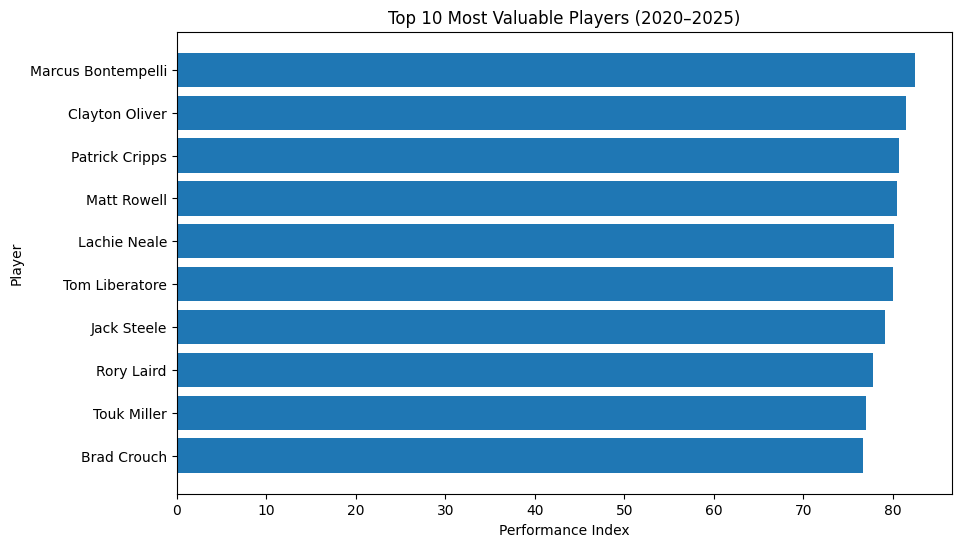

In [55]:
top_10_plot = top_10.sort_values(
    "Performance_Index"
)
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_plot["player_name"],
    top_10_plot["Performance_Index"]
)

plt.xlabel("Performance Index")
plt.ylabel("Player")
plt.title("Top 10 Most Valuable Players (2020–2025)")

plt.show()

**Most Consistent Players**

In [63]:
# Round-by-round data for consistency analysis
consistency_data = df2[
    (df2["year"] >= 2020) &
    (df2["year"] <= 2025) &
    (~df2["round"].isin(["SF", "QF", "PF", "EF", "GF"]))
].copy()

print("Consistency Data:", consistency_data.shape)

Consistency Data: (53944, 35)


In [64]:
# Player-wise Fantasy Point consistency
consistency = consistency_data.groupby('player_id').agg(
    Games=('fantasy_points', 'count'),
    Avg_Fantasy=('fantasy_points', 'mean'),
    Fantasy_SD=('fantasy_points', 'std')
).reset_index()

consistency.head()

,player_id,Games,Avg_Fantasy,Fantasy_SD
0,43260,41,42.975610,21.337160
1,43261,1,22.000000,NaN
2,43262,8,61.375000,15.990511
3,43266,106,80.396226,20.779422
4,43267,34,57.529412,20.458732


In [65]:
consistency['CV'] = (
    consistency['Fantasy_SD'] /
    consistency['Avg_Fantasy']
)

In [66]:
consistency = consistency[
    consistency['Games'] >= 30
]

In [59]:
consistency['CV'] = (
    consistency['std_fantasy'] / consistency['avg_fantasy']
)

consistency.head()

,player_id,player_name,games_played,avg_fantasy,std_fantasy,CV
0,43260,Jake Aarts,164,42.975610,21.139894,0.491904
1,43261,Ryan Abbott,4,22.000000,0.000000,0.000000
2,43262,Gary Ablett,224,61.375000,14.991253,0.244257
3,43266,Blake Acres,1590,80.396226,20.687680,0.257322
4,43267,Marcus Adams,306,57.529412,20.188638,0.350927


In [67]:
# Add player names from Players dataset
player_names = df1[
    ['player_id', 'player_name']
].drop_duplicates('player_id')

consistency = consistency.merge(
    player_names,
    on='player_id',
    how='left'
)

In [68]:
# Lowest CV = most consistent
consistent_players = (
    consistency
    .sort_values('CV', ascending=True)
    .head(10)
)

consistent_players[
    [
        'player_name',
        'Games',
        'Avg_Fantasy',
        'Fantasy_SD',
        'CV'
    ]
].round(2)

,player_name,Games,Avg_Fantasy,Fantasy_SD,CV
303,Rory Laird,124,102.90,21.62,0.21
441,Christian Petracca,120,98.73,21.02,0.21
121,Matt Crouch,55,91.49,19.50,0.21
514,Harry Sheezel,67,106.04,23.23,0.22
318,Jake Lloyd,126,88.10,19.71,0.22
519,Jayden Short,114,87.71,19.95,0.23
418,Reilly OBrien,124,89.45,20.42,0.23
438,Scott Pendlebury,114,84.69,19.35,0.23
576,Sam Walsh,107,98.30,22.60,0.23
44,Marcus Bontempelli,124,105.48,24.29,0.23


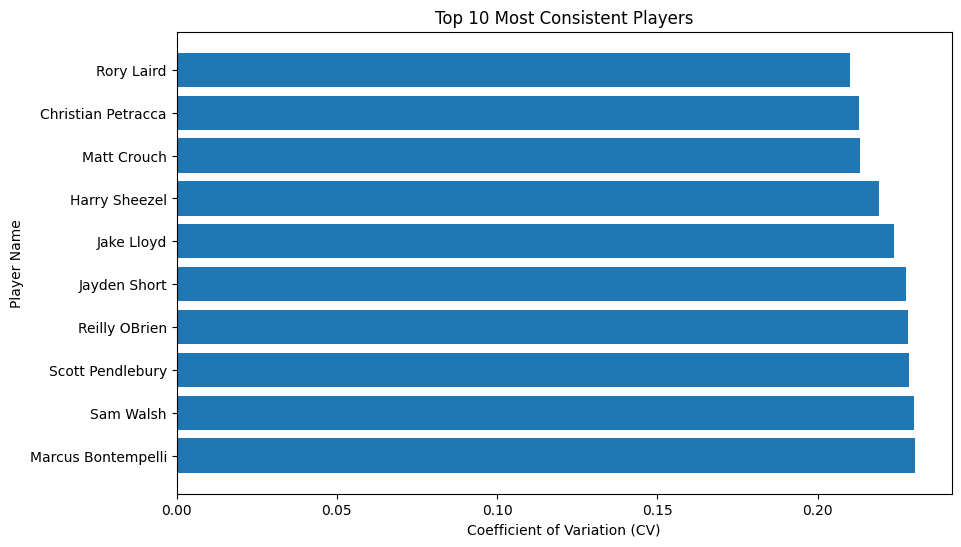

In [69]:
plt.figure(figsize=(10, 6))

plt.barh(
    consistent_players['player_name'],
    consistent_players['CV']
)

plt.xlabel('Coefficient of Variation (CV)')
plt.ylabel('Player Name')
plt.title('Top 10 Most Consistent Players')

plt.gca().invert_yaxis()
plt.show()

**Performance Trends**

In [70]:
# Performance Trends

trend_data = df2[
    (df2["year"] >= 2020) &
    (df2["year"] <= 2025) &
    (~df2["round"].isin(["SF", "QF", "PF", "EF", "GF"]))
].copy()

# Convert round to numeric
trend_data["round_num"] = pd.to_numeric(
    trend_data["round"],
    errors="coerce"
)

In [71]:
# First half: Round 1–11
first_half = trend_data[
    trend_data["round_num"] <= 11
]

# Second half: Round 12+
second_half = trend_data[
    trend_data["round_num"] > 11
]

In [72]:
# Average Fantasy Points in first half
first_half_avg = (
    first_half
    .groupby("player_id")["fantasy_points"]
    .mean()
    .reset_index(name="fantasy_points_H1")
)

# Average Fantasy Points in second half
second_half_avg = (
    second_half
    .groupby("player_id")["fantasy_points"]
    .mean()
    .reset_index(name="fantasy_points_H2")
)

In [73]:
# Merge first-half and second-half performance
player_trend = pd.merge(
    first_half_avg,
    second_half_avg,
    on="player_id",
    how="inner"
)

# Calculate performance change
player_trend["Performance_Change"] = (
    player_trend["fantasy_points_H2"]
    - player_trend["fantasy_points_H1"]
)

In [74]:
# Add player names from Players dataset
player_names = df1[
    ["player_id", "player_name"]
].drop_duplicates("player_id")

player_trend = player_trend.merge(
    player_names,
    on="player_id",
    how="left"
)

player_trend.head()

,player_id,fantasy_points_H1,fantasy_points_H2,Performance_Change,player_name
0,43260,44.739130,40.722222,-4.016908,Jake Aarts
1,43262,61.428571,61.000000,-0.428571,Gary Ablett
2,43266,79.574074,81.250000,1.675926,Blake Acres
3,43267,61.150000,52.357143,-8.792857,Marcus Adams
4,43269,77.466667,82.791667,5.325000,Taylor Adams


In [75]:
improved_players = (
    player_trend
    .sort_values("Performance_Change", ascending=False)
    .head(10)
)

print("TOP 10 MOST IMPROVED PLAYERS")

display(
    improved_players[
        [
            "player_name",
            "fantasy_points_H1",
            "fantasy_points_H2",
            "Performance_Change"
        ]
    ].round(2)
)

TOP 10 MOST IMPROVED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
292,Bryce Gibbs,28.00,90.00,62.00
119,Josh Carmichael,8.00,54.00,46.00
975,Will Martyn,13.00,58.00,45.00
504,NaN,13.00,58.00,45.00
123,Ben Cavarra,17.00,55.50,38.50
916,Ashton Moir,5.00,42.80,37.80
54,Jaxon Binns,38.25,75.50,37.25
946,Connor Downie,0.00,36.00,36.00
221,NaN,0.00,36.00,36.00
729,Angus Sheldrick,37.75,73.71,35.96


In [76]:
declined_players = (
    player_trend
    .sort_values("Performance_Change", ascending=True)
    .head(10)
)

print("TOP 10 MOST DECLINED PLAYERS")

display(
    declined_players[
        [
            "player_name",
            "fantasy_points_H1",
            "fantasy_points_H2",
            "Performance_Change"
        ]
    ].round(2)
)

TOP 10 MOST DECLINED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
969,Sam Lalor,59.10,4.00,-55.10
322,Cooper Hamilton,51.00,0.00,-51.00
287,Taylor Garner,81.33,37.67,-43.67
689,Ben Ronke,48.67,6.75,-41.92
652,Braydon Preuss,98.67,59.14,-39.52
672,Zach Reid,62.18,23.00,-39.18
938,Angus Clarke,98.00,59.46,-38.54
930,Riley Bice,71.10,32.67,-38.43
158,Charlie Constable,55.25,18.00,-37.25
42,Tom Bellchambers,50.83,15.00,-35.83


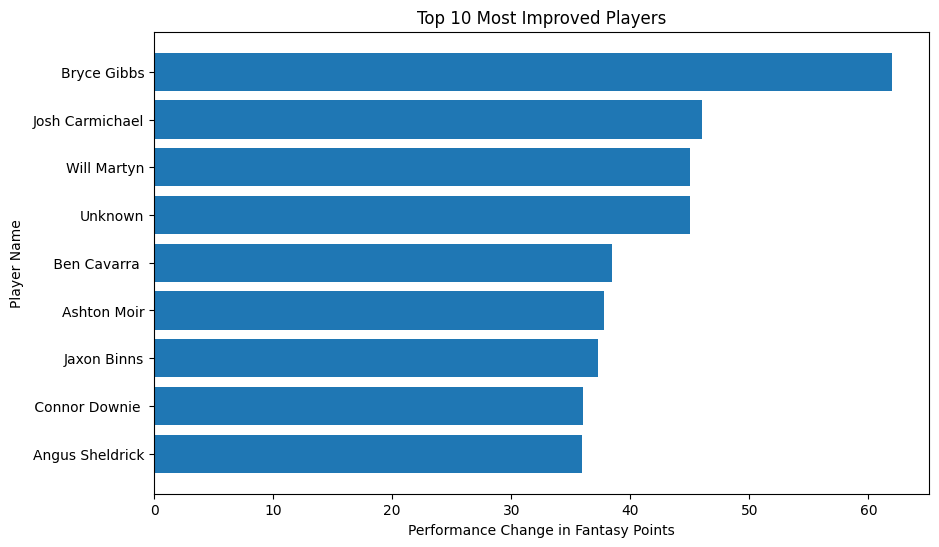

In [78]:
# Fix player names for visualization
improved_plot = improved_players.copy()

improved_plot['player_name'] = (
    improved_plot['player_name']
    .fillna('Unknown')
    .astype(str)
)

improved_plot['Performance_Change'] = pd.to_numeric(
    improved_plot['Performance_Change'],
    errors='coerce'
)

plt.figure(figsize=(10, 6))

plt.barh(
    improved_plot['player_name'],
    improved_plot['Performance_Change']
)

plt.xlabel('Performance Change in Fantasy Points')
plt.ylabel('Player Name')
plt.title('Top 10 Most Improved Players')

plt.gca().invert_yaxis()
plt.show()

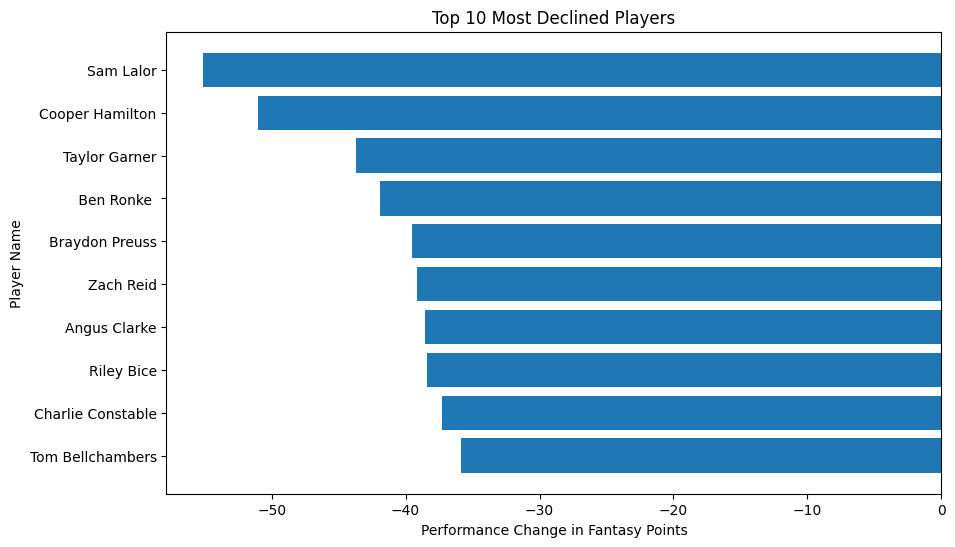

In [79]:
# Fix player names for visualization
declined_plot = declined_players.copy()

declined_plot['player_name'] = (
    declined_plot['player_name']
    .fillna('Unknown')
    .astype(str)
)

declined_plot['Performance_Change'] = pd.to_numeric(
    declined_plot['Performance_Change'],
    errors='coerce'
)

plt.figure(figsize=(10, 6))

plt.barh(
    declined_plot['player_name'],
    declined_plot['Performance_Change']
)

plt.xlabel('Performance Change in Fantasy Points')
plt.ylabel('Player Name')
plt.title('Top 10 Most Declined Players')

plt.gca().invert_yaxis()
plt.show()

**Team Performance Analysis**

In [95]:
# Filter 2020 to 2025 AND Exclude Finals
df_filtered = df2[
    (df2["year"] >= 2020) &
    (df2["year"] <= 2025) &
    (~df2["round"].isin(["SF", "QF", "PF", "EF", "GF"]))
].copy()

# Clean Team Names
df_filtered["team"] = (
    df_filtered["team"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Perform Groupby & Ranking
team_performance = (
    df_filtered.groupby("team")
    .agg(
        Player_Games=("player_id", "count"),
        Average_Fantasy=("fantasy_points", "mean"),
        Average_Disposals=("disposals", "mean"),
        Average_Clearances=("clearances", "mean"),
        Average_Goals=("goals", "mean"),
        Average_Tackles=("tackles", "mean"),
    )
    .reset_index()
)

In [97]:
# Rank teams by average Fantasy Points
team_performance["Team_Rank"] = (
    team_performance["Average_Fantasy"]
    .rank(ascending=False, method="min")
    .astype(int)
)

team_performance = team_performance.sort_values("Team_Rank")

print("Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)")

display(
    team_performance[
        [
            "Team_Rank",
            "team",
            "Player_Games",
            "Average_Fantasy",
            "Average_Disposals",
            "Average_Clearances",
            "Average_Goals",
            "Average_Tackles"
        ]
    ].round(2)
)

Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)


,Team_Rank,team,Player_Games,Average_Fantasy,Average_Disposals,Average_Clearances,Average_Goals,Average_Tackles
14,1,St Kilda Saints,2993,67.28,14.81,1.50,0.48,2.60
6,2,Geelong Cats,3022,66.95,14.31,1.61,0.58,2.58
17,3,Western Bulldogs,2976,66.69,15.36,1.71,0.57,2.53
1,4,Brisbane Lions,3038,66.09,14.35,1.69,0.57,2.43
8,5,Greater Western Sydney Giants,3017,65.86,15.07,1.54,0.52,2.63
3,6,Collingwood Magpies,3026,65.85,14.45,1.57,0.52,2.63
2,7,Carlton Blues,3030,65.76,14.67,1.64,0.51,2.57
12,8,Port Adelaide Power,2973,65.65,14.32,1.62,0.52,2.66
15,9,Sydney Swans,2988,65.58,14.63,1.56,0.54,2.66
4,10,Essendon Bombers,2988,65.50,15.14,1.47,0.48,2.42


** Final Recruitment Recommendations**

In [98]:
# Calculate player stats using round-by-round fantasy performance

player_stats = df2[
    (df2["year"] >= 2020) &
    (df2["year"] <= 2025) &
    (~df2["round"].isin(["SF", "QF", "PF", "EF", "GF"]))
].groupby("player_id")["fantasy_points"].agg(
    Games="count",
    Avg_Points="mean",
    Std_Dev="std"
).reset_index()

# Calculate consistency
player_stats["CV"] = (
    player_stats["Std_Dev"] /
    player_stats["Avg_Points"]
)

# Merge performance trends
merged_data = player_stats.merge(
    player_trend[["player_id", "Performance_Change"]],
    on="player_id",
    how="left"
)

# Add player names
merged_data = merged_data.merge(
    df1[["player_id", "player_name"]].drop_duplicates("player_id"),
    on="player_id",
    how="left"
)

# Players with at least 30 games
final_players = merged_data[
    merged_data["Games"] >= 30
].copy()

# Missing performance changes = 0
final_players["Performance_Change"] = (
    final_players["Performance_Change"].fillna(0)
)

# Recruitment Score
final_players["Recruitment_Score"] = (
    final_players["Avg_Points"]
    - (final_players["CV"] * 10)
    + (final_players["Performance_Change"] * 0.5)
)

# Top 5 Recommended Players
top_5_players = (
    final_players
    .sort_values(
        by="Recruitment_Score",
        ascending=False
    )
    .head(5)
)

print("--- TOP 5 RECOMMENDED PLAYERS ---")

display(
    top_5_players[
        [
            "player_name",
            "Games",
            "Avg_Points",
            "CV",
            "Performance_Change",
            "Recruitment_Score"
        ]
    ].round(2)
)

--- TOP 5 RECOMMENDED PLAYERS ---


,player_name,Games,Avg_Points,CV,Performance_Change,Recruitment_Score
73,Marcus Bontempelli,124,105.48,0.23,12.90,109.62
487,Rory Laird,124,102.90,0.21,11.41,106.50
604,Zach Merrett,124,106.39,0.23,4.55,106.36
542,Rowan Marshall,120,101.63,0.29,13.92,105.70
839,Jack Steele,121,104.56,0.23,4.50,104.50


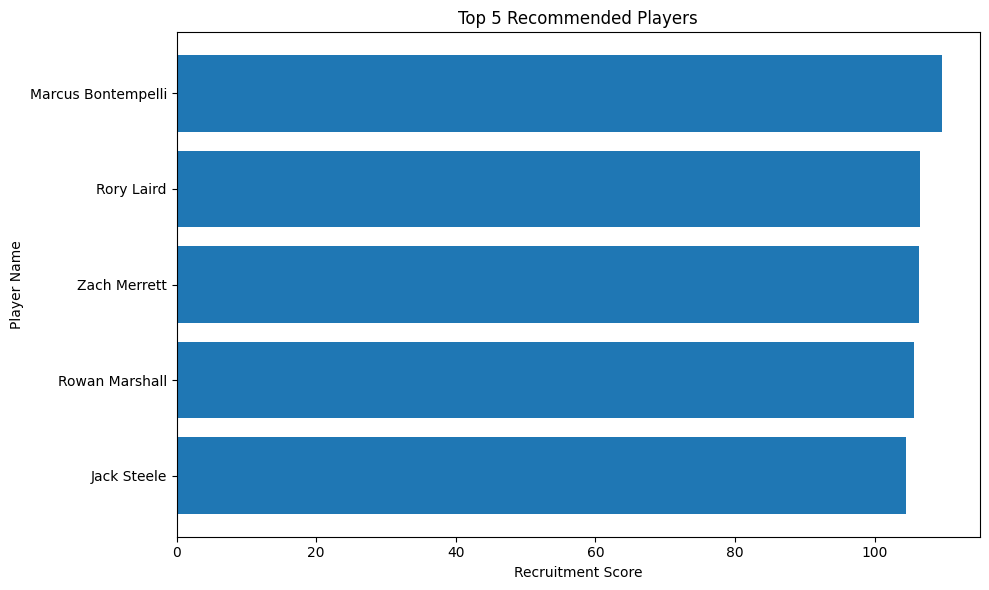

In [100]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_5_players["player_name"],
    top_5_players["Recruitment_Score"]
)

plt.xlabel("Recruitment Score")
plt.ylabel("Player Name")
plt.title("Top 5 Recommended Players")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

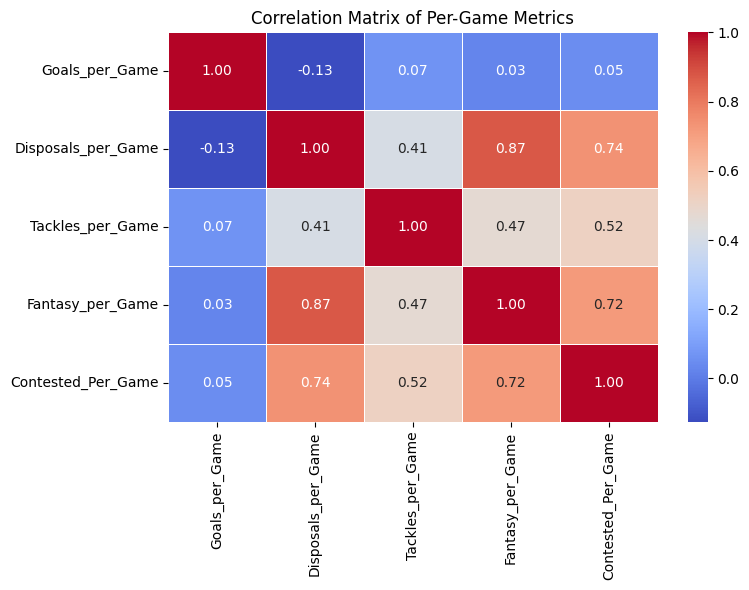

In [103]:
# Create per-game features in players

players = players.copy()

players["Goals_per_Game"] = (
    players["goals"] / players["games_played"].replace(0, pd.NA)
)

players["Disposals_per_Game"] = (
    players["disposals"] / players["games_played"].replace(0, pd.NA)
)

players["Tackles_per_Game"] = (
    players["tackles"] / players["games_played"].replace(0, pd.NA)
)

players["Fantasy_per_Game"] = (
    players["total_fantasy_points"] /
    players["games_played"].replace(0, pd.NA)
)

players["Contested_Per_Game"] = (
    players["contested_possessions"] /
    players["games_played"].replace(0, pd.NA)
)


# Correlation Matrix

cols = [
    "Goals_per_Game",
    "Disposals_per_Game",
    "Tackles_per_Game",
    "Fantasy_per_Game",
    "Contested_Per_Game"
]

corr = players[cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Per-Game Metrics")
plt.tight_layout()
plt.show()

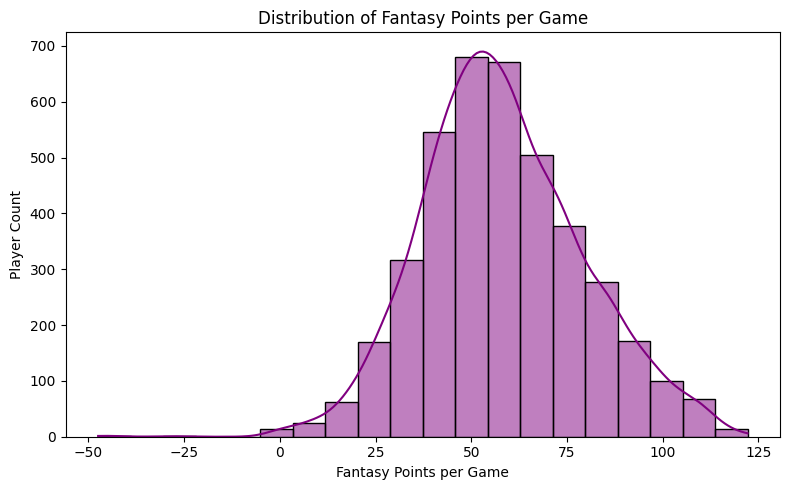

In [104]:
# Visualization 8: Histogram with KDE

plt.figure(figsize=(8, 5))

sns.histplot(
    players["Fantasy_per_Game"].dropna(),
    kde=True,
    color="purple",
    bins=20
)

plt.title("Distribution of Fantasy Points per Game")
plt.xlabel("Fantasy Points per Game")
plt.ylabel("Player Count")

plt.tight_layout()
plt.show()

## Business Insights

1. High fantasy points show good player performance.
2. Low CV means the player is more consistent.
3. Players with 30+ games give more reliable results.
4. Positive Performance Change shows player improvement.
5. Negative Performance Change shows player decline.
6. Per-game features make player comparison easier.
7. Fantasy Points per Game shows average game performance.
8. Goals, tackles, disposals and clearances show different player skills.
9. Team ranking helps compare team performance.
10. Recruitment should consider performance, consistency and improvement.
